# World Tracing — multilayer-geometry diffusion on Apple Silicon (MPS)

This notebook runs the released **image → multilayer 3D** flow-matching diffusion
model on a Mac GPU via PyTorch's **MPS** backend (no CUDA required).

The repo was originally CUDA-only. The changes that make MPS work:

* **`wt.cli.pick_device()`** — selects `cuda → mps → cpu`.
* **`wt.cli.autocast_for(device)`** — `bfloat16` autocast on CUDA, full **fp32**
  (no autocast) on MPS/CPU. The model forces fp32 for SVD-based pose solving via
  `torch.autocast(device_type="cuda", enabled=False)` guards; those only disable
  *CUDA* autocast, so enabling MPS bf16 autocast globally would corrupt those
  regions. Running fp32 keeps the non-CUDA path faithful.
* **`flash_attention`** now falls back to `F.scaled_dot_product_attention` on
  non-CUDA devices (flash-attn is CUDA-only and isn't installed here), and the
  internal length tensors are copied with `non_blocking=False` on MPS
  (`non_blocking=True` host→device copies return garbage on MPS).

**Kernel:** select **Python (world_tracing)**.

> First run downloads the checkpoint (~GBs) from the Hugging Face Hub into
> `~/.cache/huggingface/`. The object model `r75b` is used below; switch
> `CONFIG`/`CKPT` for the scene (`r69e`) or dynamic (`r76`) models.

## 1. Imports & device selection

In [1]:
import time

import numpy as np
import torch
from PIL import Image
from IPython.display import display

from wt import inference_diffusion, solve_intrinsics_from_xyz
from wt.checkpoint import CONFIGS, build_model_and_load_ckpt
from wt.cli import autocast_for, pick_device
from wt.data import load_rgba_image, preprocess_rgba_for_model
from wt.inference import _bypass_activation_checkpointing

device = pick_device()
print(f"torch {torch.__version__}")
print(f"mps available: {torch.backends.mps.is_available()} | cuda available: {torch.cuda.is_available()}")
print(f"selected device: {device}")
print(f"available configs: {sorted(CONFIGS.keys())}")

torch 2.12.1
mps available: True | cuda available: False
selected device: mps
available configs: ['r69e', 'r69g', 'r69g_mix', 'r69l', 'r75b', 'r76']


## 2. Choose model + input, then build it

`CKPT` may be a bare config name (downloads the released weights from HF Hub),
an `hf://owner/repo` URI, or a local `.pt`/`.safetensors` path.

In [2]:
CONFIG = "r75b"   # object model, 504x504, 1.7B params
CKPT = "r75b"     # bare config name -> downloads from Hugging Face Hub on first use
IMAGE = "../examples/test_images/object/obj014_leather_briefcase.png"
SEED = 42

print(f"building model (config={CONFIG}) on {device} — first run downloads weights ...")
t0 = time.time()
model, cfg = build_model_and_load_ckpt(CONFIG, CKPT, device)
model.eval()
print(f"model ready in {time.time() - t0:.1f}s | image_size={cfg['image_size']} | num_layers={cfg['model_kwargs']['num_layers']}")

building model (config=r75b) on mps — first run downloads weights ...
2026-06-18 16:58:31 [info     ] Activation checkpointing enabled in 42 decoder blks
2026-06-18 16:58:31 [info     ] Decoder attention pattern: frame_ray_global (disabled RoPE on 14 ray-wise blocks)
2026-06-18 16:58:31 [info     ] Split-token depth_only mode: geo_raw_dim=1176, nc_geo=3, no mask_noise_projection/type_embed.
2026-06-18 16:58:32 [info     ] Head FiLM enabled: independent layer embedding + FiLM projection per head (num_layers=6, zero-init).
2026-06-18 16:58:32 [info     ] Using split transformer heads (SplitTransformerProjection, 6 blocks, geo-only(3ch) + head_film, attn=frame_ray_global + timestep, alternating frame-wise/ray-wise/global).
2026-06-18 16:58:32 [info     ] Layer embed mode: film (per-layer FiLM scale/shift at frame-wise blocks, zero-init).
2026-06-18 16:58:32 [info     ] MultilayerXYZModel initialized total_params=1705.047628 trainable_params=1394.385996
[wt] r75b: model params: 1705.0M
[wt

## 3. Load & preprocess the input image

loaded RGBA: (768, 1376, 4)


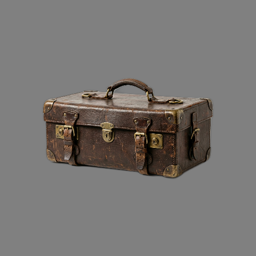

In [3]:
rgba = load_rgba_image(IMAGE, auto_alpha=True)
print(f"loaded RGBA: {rgba.shape}")

rgb_t, mask_t, intr_t = preprocess_rgba_for_model(
    rgba,
    image_size=cfg["image_size"],
    num_layers=cfg["model_kwargs"]["num_layers"],
    alpha_erode_px=0,
    center_crop=True,
    bg_color=(128, 128, 128),
)
rgb_t = rgb_t.to(device)
mask_t = mask_t.to(device)
intr_t = intr_t.to(device)

# show the (preprocessed) RGB fed to the model
rgb_uint8 = (rgb_t[0].permute(1, 2, 0).cpu().numpy() * 255.0).astype(np.uint8)
display(Image.fromarray(rgb_uint8).resize((256, 256)))

## 4. Run the diffusion forward pass on MPS

Single deterministic seed for speed. On MPS this runs in fp32; expect it to be
noticeably slower than a CUDA GPU.

In [4]:
torch.manual_seed(SEED)

t0 = time.time()
with torch.no_grad(), autocast_for(device), _bypass_activation_checkpointing(model):
    xyz_pred, mask_pred, _ = inference_diffusion(
        model,
        rgb_t,
        gt_mask=mask_t,
        use_gt_mask=True,
        intrinsics=intr_t,
        invalid_fill_mode="noise",
        **cfg["inference_kwargs"],
    )
if device.type == "mps":
    torch.mps.synchronize()
print(f"diffusion done in {time.time() - t0:.1f}s")

xyz = xyz_pred[0].float().cpu().numpy()          # [L, H, W, 3]
mask = mask_pred[0].cpu().numpy().astype(bool)   # [L, H, W]
print(f"xyz: {xyz.shape} | mask: {mask.shape} | predicted layers: {xyz.shape[0]}")

/Users/annhe/world-tracing/wt/_core/arch/models/backbone.py:674: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  type_ctx = torch.autocast(device_type="cuda", dtype=autocast_dtype)
/Users/annhe/world-tracing/wt/model.py:3184: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast(device_type="cuda", dtype=torch.float32):
/Users/annhe/world-tracing/wt/_core/arch/models/backbone.py:1516: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
/Users/annhe/world-tracing/wt/model.py:625: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast(device_type="cuda", dtype=torch.float32):
/Users/annhe/world-tracing/wt/model.py:1789: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast(device_type="cuda", dtype=torch.float32):


diffusion done in 129.8s
xyz: (6, 504, 504, 3) | mask: (6, 504, 504) | predicted layers: 6


## 5. Inspect the prediction

Solve camera intrinsics from the front layer and render each layer's depth (the
camera-space `Z`) as a quick inline sanity check — layer 0 is the visible
surface; later layers fill in the occluded geometry behind it.

solved K from layer-0 XYZ; fov_x ≈ 28.6°
per-layer depth (Z), front → back:


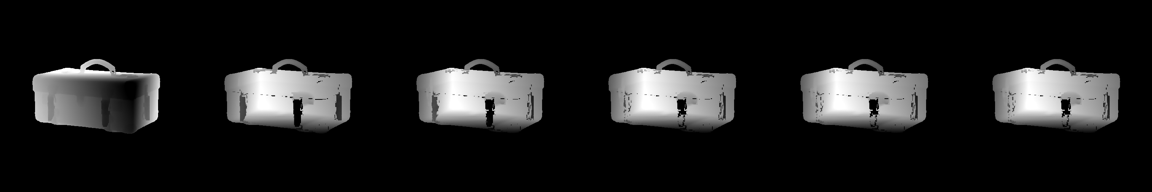

layer 0: valid px=  49064 | Z range [1.663, 2.112]
layer 1: valid px=  49064 | Z range [1.680, 2.249]
layer 2: valid px=  49064 | Z range [1.677, 2.249]
layer 3: valid px=  49064 | Z range [1.678, 2.249]
layer 4: valid px=  49064 | Z range [1.678, 2.249]
layer 5: valid px=  49064 | Z range [1.678, 2.249]


In [5]:
K_solved, fov_x = solve_intrinsics_from_xyz(xyz[0], mask[0], image_size=cfg["image_size"])
print(f"solved K from layer-0 XYZ; fov_x ≈ {fov_x:.1f}°")

def depth_to_img(z, m):
    """Normalize a depth (Z) map within its valid mask to a uint8 grayscale image."""
    vis = np.zeros_like(z, dtype=np.uint8)
    if m.any():
        zv = z[m]
        lo, hi = np.percentile(zv, 2), np.percentile(zv, 98)
        norm = np.clip((z - lo) / max(hi - lo, 1e-6), 0, 1)
        vis = (norm * 255).astype(np.uint8)
        vis[~m] = 0
    return Image.fromarray(vis).resize((192, 192))

L = xyz.shape[0]
strip = Image.new("L", (192 * L, 192), color=0)
for i in range(L):
    strip.paste(depth_to_img(xyz[i, :, :, 2], mask[i]), (192 * i, 0))
print("per-layer depth (Z), front → back:")
display(strip)

for i in range(L):
    valid = int(mask[i].sum())
    z = xyz[i, :, :, 2][mask[i]] if valid else np.array([0.0])
    print(f"layer {i}: valid px={valid:>7d} | Z range [{z.min():.3f}, {z.max():.3f}]")

## 6. (Optional) Export a Rerun `.rrd` for interactive 3D viewing

Writes a `.rrd` you can open with `rerun out_mps.rrd` (requires the `viz`
extra, already installed in this env).

In [6]:
from wt.viz import init_recording, log_prediction, save_rrd

K_for_viz = K_solved if K_solved is not None else intr_t[0].cpu().numpy()
rec = init_recording(application_id=f"wt.{CONFIG}.mps")
log_prediction(
    rgb_uint8=rgb_uint8,
    xyz=xyz,
    mask=mask,
    intrinsics=K_for_viz,
    name=IMAGE.split("/")[-1],
    recording=rec,
)
rrd_path = save_rrd(rec, "out_mps.rrd")
print(f"wrote {rrd_path}\nview with: rerun {rrd_path}")

wrote /Users/annhe/world-tracing/notebooks/out_mps.rrd
view with: rerun /Users/annhe/world-tracing/notebooks/out_mps.rrd
